# Ensemble Fuzzy — Pertinência Emocional (GoEmotionsPT-BR)

Este notebook implementa o **Ensemble Fuzzy** que combina os dois baselines já treinados
(**Logistic Regression + TF-IDF** e **BERTimbau-base cross-balanced**) para detecção
multi-label de emoções no GoEmotions traduzido para português, seguindo a metodologia
proposta e com base teórica em:

> Anwar, Z. et al. (2024). *Fuzzy ensemble of fine-tuned BERT models for domain-specific
> sentiment analysis of software engineering dataset*. PLoS ONE 19(5): e0300279.

Assim como no artigo, o ensemble é um **sistema fuzzy Mamdani Tipo-1**: as saídas dos
classificadores individuais entram como variáveis de entrada de um sistema de inferência
fuzzy, cujas funções de pertinência e regras combinam as forças de cada modelo. As
adaptações em relação ao artigo são: (i) o problema aqui é **multi-label** (28 emoções),
então há um sistema fuzzy por emoção; (ii) em vez de ajustar as MFs por Algoritmo Genético,
as variáveis linguísticas/MFs são geradas **automaticamente via Fuzzy C-Means (FCM)** e a
base de regras é gerada **automaticamente a partir dos dados (método de Wang–Mendel)** —
ambos calibrados apenas no outer-train, preservando o protocolo de Nested CV.

**Motivação central**: o LR baseline apresenta **Recall mais alto** (capta mais emoções
verdadeiras, ao custo de falsos positivos) e o BERTimbau apresenta **Precision mais alta**
(erra menos quando afirma, mas perde positivos). O sistema fuzzy é calibrado para
**juntar "as melhores partes"**: confiar no BERT quando ele afirma com força (precisão)
e recuperar positivos sinalizados pelo LR quando o contexto de sentimento/léxico é
coerente (recall).

### Mapeamento para a metodologia (blocos 1–9 do diagrama)

| Bloco | Onde neste notebook |
|---|---|
| 1. Benchmark e Protocolo (GoEmotions-BR, 5-Fold Nested CV) | §1–§2 |
| 2. Modelo Baseline → `P_LR(emoção)` | §3 (predições out-of-fold em cache) |
| 3. Modelo Transformer → `P_BERT(emoção)` | §3 (inferência dos checkpoints por fold) |
| 4. Features de Sentimento (`sent_pos`, `sent_neg`, `sent_neu`) | §4 (léxico **ou** BERT de sentimento) |
| 5. Sistema Fuzzy de Pertinência Emocional (entradas) | §5–§6 |
| 6. Conjuntos Nebulosos (Fuzzy C-Means) | §6 — geração automática de variáveis linguísticas e MFs |
| 7. Regras de Inferência (geração automática) | §6 — Wang–Mendel a partir dos dados |
| 8. Inferência e Defuzzificação (Centroide, MOM, Bisector) | §6–§7 |
| 9. Saídas: graus de pertinência (0–1) por emoção | §7 e §10 |
| Avaliação e Comparação (média ± DP, Wilcoxon, interpretabilidade) | §8–§11 |

### Protocolo Nested CV sem vazamento

Para cada **outer fold k** (teste):
- As predições `P_LR` e `P_BERT` de **todas** as amostras são *out-of-fold*: a amostra do
  fold `j` é sempre predita pelo modelo treinado **sem** o fold `j` (esquema idêntico ao
  dos baselines, reutilizando os checkpoints/hiperparâmetros do inner loop já executado).
- O sistema fuzzy (FCM, regras, limiares de decisão e escolha do método de
  defuzzificação) é **calibrado exclusivamente no outer-train** (folds `j ≠ k`) e
  **avaliado no outer-test** (fold `k`). Nada do fold `k` é visto na calibração.

Os resultados finais são reportados como **média ± desvio-padrão entre os 5 outer folds**,
com teste estatístico de **Wilcoxon** (LR vs BERTimbau vs Ensemble Fuzzy), exatamente
como nos baselines.

In [ ]:
# Dependências extras deste notebook (os baselines já cobrem o restante)
# !pip install scikit-fuzzy scipy pandas numpy scikit-learn pyarrow matplotlib imbalanced-learn
# !pip install leia-br

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import ast
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path

import skfuzzy as fuzz
from scipy.stats import wilcoxon

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─── Configurações globais ───────────────────────────────────────
RANDOM_STATE  = 42
N_OUTER_FOLDS = 5
TEXT_COL      = "CLEAN_TEXT"

DATA_DIR = Path("../data/treated")
OUT_LR   = Path("../data/out")                       # saídas do baseline LR
OUT_BERT = Path("../data/out/bertimbau")             # saídas do baseline BERTimbau
CKPT_DIR = Path("../data/checkpoints/bertimbau")     # checkpoints por fold
OUT_DIR  = Path("../data/out/ensemble_fuzzy")
CACHE_DIR = OUT_DIR / "cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Backend das features de sentimento: "lexicon" (léxico PT, sem GPU) ou "bert"
SENTIMENT_BACKEND = "lexicon"
SENTIMENT_BERT_MODEL = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"

# Hiperestrutura do sistema fuzzy (fixa; toda calibração ocorre no outer-train)
FCM_C_CANDIDATES = (2, 3, 4)     # nº de conjuntos avaliados pelo FPC
MAX_RULES        = 60            # teto de regras por emoção
T_NORM           = "prod"        # t-norma dos antecedentes
DEFUZZ_METHODS   = ("centroid", "bisector", "mom")
THRESH_GRID      = np.linspace(0.05, 0.95, 19)

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

INPUT_VARS = ["p_lr", "p_bert", "sent_pos", "sent_neg", "sent_neu", "outras"]

np.random.seed(RANDOM_STATE)
print(f"Labels: {N_LABELS} | Entradas fuzzy: {INPUT_VARS}")
print(f"Cache : {CACHE_DIR.resolve()}")

Labels: 28 | Entradas fuzzy: ['p_lr', 'p_bert', 'sent_pos', 'sent_neg', 'sent_neu', 'outras']
Cache : C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy\cache


## 1–2. Benchmark, protocolo e carregamento dos folds

In [4]:
def load_fold(fold_id: int):
    """Carrega data.parquet e idx.npy de um fold. Retorna (df, idx_array)."""
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras | idx shape: {idx_k.shape}")

def prepare_Y(df: pd.DataFrame):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels no parquet: {set(EMOTION_COLS)-set(present)}"
    return df[present].values.astype(int)

Y_folds    = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
TEXT_folds = {k: folds_data[k]["df"][TEXT_COL].fillna("").astype(str).values for k in folds_data}

print("\nColunas disponíveis:", folds_data[1]["df"].columns.tolist())

Fold 1:  10831 amostras | idx shape: (10831,)
Fold 2:  10810 amostras | idx shape: (10810,)
Fold 3:  10836 amostras | idx shape: (10836,)
Fold 4:  10909 amostras | idx shape: (10909,)
Fold 5:  10848 amostras | idx shape: (10848,)

Colunas disponíveis: ['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT', 'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_rep

## 3. Predições out-of-fold — `P_LR(emoção)` e `P_BERT(emoção)`

As entradas do sistema fuzzy precisam ser **out-of-fold** para que a calibração no
outer-train não vaze informação: a amostra do fold `j` recebe a probabilidade do modelo
treinado **sem** o fold `j`.

- **`P_LR`**: retreinamos o pipeline TF-IDF + SMOTE + LR do baseline (Binary Relevance),
  reutilizando os **hiperparâmetros já otimizados no inner GridSearch**
  (`baseline_LR_best_params.csv`); se o arquivo não existir, usa os defaults do baseline.
- **`P_BERT`**: apenas **inferência** — carregamos, para cada fold, o checkpoint da
  **melhor época** (lida de `bertimbau_global_metrics.csv`, ou varrendo os checkpoints)
  e predizemos as probabilidades (sigmoid) do próprio fold.

Tudo fica em cache em `cache/P_LR_fold_k.npy` e `cache/P_BERT_fold_k.npy` — as células
abaixo só recomputam o que estiver faltando.

In [7]:
# ─── P_LR: out-of-fold do baseline Logistic Regression ──────────
def load_lr_best_params():
    fp = OUT_LR / "baseline_LR_best_params.csv"
    if not fp.exists():
        print("baseline_LR_best_params.csv não encontrado → usando defaults do baseline.")
        return None
    df = pd.read_csv(fp)
    params = {}
    for _, r in df.iterrows():
        mf = r.get("tfidf__max_features")
        ng = r.get("tfidf__ngram_range")
        p = {
            "max_features": None if pd.isna(mf) else int(mf),
            "ngram_range" : ast.literal_eval(ng) if isinstance(ng, str) else (1, 2),
            "sublinear_tf": bool(r.get("tfidf__sublinear_tf", True)),
            "C"           : 1.0 if pd.isna(r.get("lr__C")) else float(r.get("lr__C")),
        }
        params.setdefault(int(r["fold"]), {})[str(r["label"])] = p
    return params

def compute_lr_oof(missing_folds):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from imblearn.over_sampling import SMOTE

    best_params = load_lr_best_params()
    default = {"max_features": 30_000, "ngram_range": (1, 2), "sublinear_tf": True, "C": 1.0}

    for k in missing_folds:
        t0 = time.time()
        X_test_text = TEXT_folds[k]
        train_ks = [j for j in folds_data if j != k]
        X_train_text = np.concatenate([TEXT_folds[j] for j in train_ks])
        Y_train = np.vstack([Y_folds[j] for j in train_ks])

        P = np.zeros((len(X_test_text), N_LABELS), dtype=float)
        for j, lname in enumerate(EMOTION_COLS):
            p = (best_params or {}).get(k, {}).get(lname, default)
            y_j = Y_train[:, j]

            tfidf = TfidfVectorizer(max_features=p["max_features"],
                                    ngram_range=p["ngram_range"],
                                    sublinear_tf=p["sublinear_tf"])
            X_tr = tfidf.fit_transform(X_train_text)
            X_te = tfidf.transform(X_test_text)

            n_pos = int(y_j.sum()); n_neg = len(y_j) - n_pos
            if n_pos >= 2 and n_neg >= 2:
                smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, n_pos - 1))
                X_res, y_res = smote.fit_resample(X_tr, y_j)
            else:
                X_res, y_res = X_tr, y_j

            lr = LogisticRegression(C=p["C"], solver="saga", max_iter=1000,
                                    random_state=RANDOM_STATE)
            lr.fit(X_res, y_res)
            P[:, j] = lr.predict_proba(X_te)[:, 1]

        np.save(CACHE_DIR / f"P_LR_fold_{k}.npy", P)
        print(f"  P_LR fold {k} salvo ({time.time()-t0:.0f}s)")

missing = [k for k in folds_data if not (CACHE_DIR / f"P_LR_fold_{k}.npy").exists()]
if missing:
    print(f"Gerando P_LR para folds {missing}...")
    compute_lr_oof(missing)
P_LR_folds = {k: np.load(CACHE_DIR / f"P_LR_fold_{k}.npy") for k in folds_data}
print("P_LR OK:", {k: v.shape for k, v in P_LR_folds.items()})

Gerando P_LR para folds [1, 2, 3, 4, 5]...
  P_LR fold 1 salvo (97s)
  P_LR fold 2 salvo (98s)
  P_LR fold 3 salvo (85s)
  P_LR fold 4 salvo (99s)
  P_LR fold 5 salvo (86s)
P_LR OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


In [8]:
# ─── P_BERT: inferência dos checkpoints BERTimbau por fold ──────
def best_epoch_per_fold():
    """Melhor época por fold (maior F1-Macro), lida do CSV do baseline se existir."""
    fp = OUT_BERT / "bertimbau_global_metrics.csv"
    if fp.exists():
        df = pd.read_csv(fp, index_col=0)
        if "epoch" in df.columns:
            return {int(f): int(e) for f, e in df["epoch"].items()}
    return None

def compute_bert_oof(missing_folds):
    import torch
    import torch.nn as nn
    from transformers import AutoTokenizer, AutoModel

    MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
    MAX_LEN, BATCH_SIZE = 128, 64
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class BERTimbauForEmotions(nn.Module):
        def __init__(self, model_name=MODEL_NAME, n_labels=N_LABELS, dropout=0.1):
            super().__init__()
            self.bert = AutoModel.from_pretrained(model_name)
            self.dropout = nn.Dropout(dropout)
            self.classifier = nn.Linear(self.bert.config.hidden_size, n_labels)
        def forward(self, input_ids, attention_mask):
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    best_eps = best_epoch_per_fold()

    def find_ckpt(fold):
        if best_eps and fold in best_eps:
            fp = CKPT_DIR / f"fold_{fold}_epoch_{best_eps[fold]:02d}.pt"
            if fp.exists():
                return fp
        # fallback: varre os checkpoints e escolhe o de maior f1_macro
        cands = sorted(CKPT_DIR.glob(f"fold_{fold}_epoch_*.pt"))
        assert cands, f"Nenhum checkpoint encontrado para o fold {fold} em {CKPT_DIR}"
        best_fp, best_f1 = None, -1
        for fp in cands:
            ck = torch.load(fp, map_location="cpu", weights_only=False)
            f1 = ck.get("metrics", {}).get("f1_macro", -1)
            if f1 > best_f1:
                best_fp, best_f1 = fp, f1
            del ck
        return best_fp

    for k in missing_folds:
        t0 = time.time()
        ckpt_path = find_ckpt(k)
        print(f"  Fold {k}: usando {ckpt_path.name}")
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = BERTimbauForEmotions().to(DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        model.eval()

        texts = TEXT_folds[k].tolist()
        probas = []
        with torch.no_grad():
            for i in range(0, len(texts), BATCH_SIZE):
                enc = tokenizer(texts[i:i + BATCH_SIZE], max_length=MAX_LEN,
                                padding="max_length", truncation=True, return_tensors="pt")
                logits = model(enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE))
                probas.append(torch.sigmoid(logits).cpu().numpy())
        P = np.vstack(probas)
        np.save(CACHE_DIR / f"P_BERT_fold_{k}.npy", P)
        del model, ck
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print(f"  P_BERT fold {k} salvo ({time.time()-t0:.0f}s)")

missing = [k for k in folds_data if not (CACHE_DIR / f"P_BERT_fold_{k}.npy").exists()]
if missing:
    print(f"Gerando P_BERT para folds {missing}...")
    compute_bert_oof(missing)
P_BERT_folds = {k: np.load(CACHE_DIR / f"P_BERT_fold_{k}.npy") for k in folds_data}
print("P_BERT OK:", {k: v.shape for k, v in P_BERT_folds.items()})

Gerando P_BERT para folds [1, 2, 3, 4, 5]...


  Fold 1: usando fold_1_epoch_04.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 35544.95it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_BERT fold 1 salvo (29s)
  Fold 2: usando fold_2_epoch_04.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 32180.53it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

  P_BERT fold 3 salvo (28s)
  Fold 4: usando fold_4_epoch_04.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28787.56it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_BERT fold 4 salvo (28s)
  Fold 5: usando fold_5_epoch_03.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 32869.94it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  P_BERT fold 5 salvo (28s)
P_BERT OK: {1: (10831, 28), 2: (10810, 28), 3: (10836, 28), 4: (10909, 28), 5: (10848, 28)}


## 4. Features de Sentimento — `sent_pos`, `sent_neg`, `sent_neu`

Bloco 4 da metodologia. Duas opções, controladas por `SENTIMENT_BACKEND`:

- **`"lexicon"`** (default, sem GPU): léxico de polaridade em português (usa o **LeIA** —
  léxico VADER-PT — se instalado; caso contrário, um léxico embutido com tratamento de
  **negação** e **intensificadores**). Produz escores que somam 1.
- **`"bert"`**: um segundo BERT de sentimento (`{pos, neu, neg}` via softmax), independente
  dos dois classificadores do ensemble.

As três features entram no sistema fuzzy como contexto: p.ex., uma emoção positiva
(`joy`, `gratitude`) sinalizada pelo LR fica mais crível se `sent_pos` é alto — é esse
tipo de coerência que as regras aprendem para recuperar o recall sem sacrificar precisão.

In [9]:
# ─── Léxico embutido (fallback) ──────────────────────────────────
_POS_WORDS = set("""
bom boa bons boas ótimo otimo ótima otima excelente maravilhoso maravilhosa incrível incrivel
adorável adoravel lindo linda legal bacana top perfeito perfeita amei amo adoro adorei gostei
gosto feliz felicidade alegria alegre contente animado animada empolgado empolgada grato grata
gratidão gratidao obrigado obrigada parabéns parabens sucesso vitória vitoria ganhei ganhou
melhor melhores fantástico fantastico sensacional espetacular impressionante admirável admiravel
orgulho orgulhoso orgulhosa esperança esperanca otimista confiante seguro segura tranquilo
tranquila calmo calma paz amor amoroso carinho carinhoso querido querida fofo fofa doce gentil
bondade generoso generosa ajuda apoio incentivo divertido divertida engraçado engracado hilário
hilario risada rir sorrir sorriso curti curtir aprovado aprovo concordo certo certeza justo
interessante curioso curiosa surpreendente maravilha bênção bencao abençoado abencoado alívio
alivio aliviado aliviada satisfeito satisfeita realizado realizada encantado encantada desejo
vontade animação animacao entusiasmo prazer favorito favorita recomendo valeu incrivelmente
""".split())

_NEG_WORDS = set("""
ruim péssimo pessimo péssima pessima horrível horrivel terrível terrivel odeio odiei ódio odio
raiva irritado irritada irritante bravo brava furioso furiosa nervoso nervosa medo assustado
assustada pavor terror pânico panico ansioso ansiosa ansiedade preocupado preocupada triste
tristeza deprimido deprimida depressão depressao chorar chorando lágrima lagrima sofrimento
sofrer dor doloroso dolorosa mágoa magoa magoado magoada decepção decepcao decepcionado
decepcionada frustrado frustrada frustração frustracao desapontado desapontada nojo nojento
nojenta repugnante vergonha envergonhado envergonhada constrangedor constrangido humilhante
humilhado culpa culpado culpada arrependido arrependida remorso lamentável lamentavel lamento
infelizmente infeliz azar fracasso fracassado perdi perdeu derrota falha falhou erro errado
errada injusto injusta absurdo ridículo ridiculo idiota estúpido estupido burro burra chato
chata cansado cansada estresse estressado estressada desisto desistir sozinho sozinha solidão
solidao abandonado abandonada morte morto morta luto perda saudade discordo reprovado detesto
detestável detestavel pior piores nunca jamais problema problemas crise desastre trágico tragico
""".split())

_INTENSIFIERS = set("muito muitíssimo muitissimo extremamente super bem tão tao totalmente "
                    "completamente demais absurdamente incrivelmente realmente".split())
_NEGATIONS = set("não nao nunca jamais nem sem nada nenhum nenhuma".split())

_token_re = re.compile(r"[a-záàâãéêíóôõúüç]+", re.IGNORECASE)

def _lexicon_scores(text: str):
    toks = _token_re.findall(text.lower())
    pos = neg = 0.0
    for i, t in enumerate(toks):
        w = 0.0
        if t in _POS_WORDS: w = 1.0
        elif t in _NEG_WORDS: w = -1.0
        if w == 0.0:
            continue
        window = toks[max(0, i - 3):i]
        if any(x in _INTENSIFIERS for x in window):
            w *= 1.5
        if any(x in _NEGATIONS for x in window):
            w *= -1.0
        if w > 0: pos += w
        else:     neg += -w
    denom = pos + neg + 1.0
    return pos / denom, neg / denom, 1.0 / denom   # somam 1

def sentiment_features_lexicon(texts):
    # tenta LeIA (VADER-PT); senão, léxico embutido
    try:
        from leia import SentimentIntensityAnalyzer
        sia = SentimentIntensityAnalyzer()
        out = np.array([[s["pos"], s["neg"], s["neu"]]
                        for s in (sia.polarity_scores(t) for t in texts)], dtype=float)
        print("  (backend: LeIA)")
        return out
    except Exception:
        return np.array([_lexicon_scores(t) for t in texts], dtype=float)

def sentiment_features_bert(texts, batch_size=64):
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tok = AutoTokenizer.from_pretrained(SENTIMENT_BERT_MODEL)
    mdl = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_BERT_MODEL).to(device).eval()
    id2label = {i: l.lower() for i, l in mdl.config.id2label.items()}
    order = [next(i for i, l in id2label.items() if l.startswith(p))
             for p in ("pos", "neg", "neu")]
    outs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok(list(texts[i:i + batch_size]), max_length=128, padding=True,
                      truncation=True, return_tensors="pt").to(device)
            probs = torch.softmax(mdl(**enc).logits, dim=-1).cpu().numpy()
            outs.append(probs[:, order])
    return np.vstack(outs)

def get_sentiment_features():
    sent = {}
    for k in folds_data:
        fp = CACHE_DIR / f"SENT_{SENTIMENT_BACKEND}_fold_{k}.npy"
        if fp.exists():
            sent[k] = np.load(fp)
            continue
        print(f"Calculando sentimento ({SENTIMENT_BACKEND}) — fold {k}...")
        texts = TEXT_folds[k]
        S = (sentiment_features_bert(texts) if SENTIMENT_BACKEND == "bert"
             else sentiment_features_lexicon(texts))
        np.save(fp, S)
        sent[k] = S
    return sent

SENT_folds = get_sentiment_features()   # (n, 3): sent_pos, sent_neg, sent_neu
print("Sentimento OK:", {k: v.shape for k, v in SENT_folds.items()})
print("Exemplo fold 1 (5 primeiras):")
print(pd.DataFrame(SENT_folds[1][:5], columns=["sent_pos", "sent_neg", "sent_neu"]).round(3))

Calculando sentimento (lexicon) — fold 1...
Calculando sentimento (lexicon) — fold 2...
Calculando sentimento (lexicon) — fold 3...
Calculando sentimento (lexicon) — fold 4...
Calculando sentimento (lexicon) — fold 5...
Sentimento OK: {1: (10831, 3), 2: (10810, 3), 3: (10836, 3), 4: (10909, 3), 5: (10848, 3)}
Exemplo fold 1 (5 primeiras):
   sent_pos  sent_neg  sent_neu
0     0.000       0.0     1.000
1     0.667       0.0     0.333
2     0.667       0.0     0.333
3     0.600       0.0     0.400
4     0.000       0.0     1.000


## 5. Outras features (léxicas/linguísticas)

Bloco "Outras features" do sistema fuzzy. Se o parquet já traz **features léxicas
pré-calculadas** (as mesmas usadas junto ao LR), elas são reaproveitadas; caso contrário,
são extraídas do texto as features linguísticas clássicas de **intensidade emocional**
(exclamações, interrogações, caixa alta, alongamentos, emojis/emoticons, tamanho).
Elas são agregadas em uma única variável de entrada `outras ∈ [0,1]` (normalização
min–max ajustada **apenas no outer-train** dentro do loop).

In [10]:
_elong_re  = re.compile(r"(\w)\1{2,}")
_emoji_re  = re.compile("[\U0001F300-\U0001FAFF\u2600-\u27BF]")
_emot_re   = re.compile(r"[:;=8][\-']?[\)\(dpDP/\\oO3]")

def linguistic_features_from_text(texts):
    feats = np.zeros((len(texts), 6), dtype=float)
    for i, t in enumerate(texts):
        n = max(len(t), 1)
        toks = t.split()
        feats[i, 0] = t.count("!")
        feats[i, 1] = t.count("?")
        feats[i, 2] = sum(1 for c in t if c.isupper()) / n
        feats[i, 3] = len(_elong_re.findall(t))
        feats[i, 4] = len(_emoji_re.findall(t)) + len(_emot_re.findall(t))
        feats[i, 5] = min(len(toks) / 50.0, 1.0)
    return feats

def get_lexical_features():
    # 1) tenta reaproveitar colunas numéricas extras do parquet (features do LR)
    df0 = folds_data[1]["df"]
    skip = set(EMOTION_COLS) | {TEXT_COL}
    extra_cols = [c for c in df0.columns
                  if c not in skip and pd.api.types.is_numeric_dtype(df0[c])]
    lex = {}
    if extra_cols:
        print(f"Reaproveitando {len(extra_cols)} features léxicas do parquet: {extra_cols}")
        for k in folds_data:
            lex[k] = folds_data[k]["df"][extra_cols].values.astype(float)
        return lex, extra_cols
    # 2) fallback: extrai do texto
    names = ["n_exclam", "n_quest", "caps_ratio", "n_elong", "n_emoji", "len_norm"]
    print("Sem features léxicas no parquet → extraindo do texto:", names)
    for k in folds_data:
        fp = CACHE_DIR / f"LEX_fold_{k}.npy"
        lex[k] = np.load(fp) if fp.exists() else linguistic_features_from_text(TEXT_folds[k])
        np.save(fp, lex[k])
    return lex, names

LEX_folds, LEX_NAMES = get_lexical_features()
print("Features léxicas OK:", {k: v.shape for k, v in LEX_folds.items()})

def aggregate_outras(lex_train, lex_apply):
    """Agrega a matriz léxica em um escalar 'outras' em [0,1].
    Normalização por quantis (1%, 99%) ajustada SOMENTE no treino (sem vazamento)."""
    lo = np.quantile(lex_train, 0.01, axis=0)
    hi = np.quantile(lex_train, 0.99, axis=0)
    rng = np.where(hi - lo < 1e-9, 1.0, hi - lo)
    def _t(M):
        return np.clip((M - lo) / rng, 0, 1).mean(axis=1)
    return _t(lex_train), _t(lex_apply)

Reaproveitando 16 features léxicas do parquet: ['letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_repetition_per_word']
Features léxicas OK: {1: (10831, 16), 2: (10810, 16), 3: (10836, 16), 4: (10909, 16), 5: (10848, 16)}


## 6. Sistema Fuzzy de Pertinência Emocional (blocos 5–8)

Um **sistema Mamdani Tipo-1 por emoção**, com 6 variáveis de entrada
(`p_lr`, `p_bert`, `sent_pos`, `sent_neg`, `sent_neu`, `outras`) e uma saída:
a **pertinência emocional** ∈ [0,1] — o grau com que o texto *pertence* àquela emoção.

**Conjuntos nebulosos (Fuzzy C-Means)** — para cada variável de entrada, o FCM
(Bezdek, m=2) agrupa os valores observados no outer-train; o número de conjuntos
`c ∈ {2,3,4}` é escolhido automaticamente pelo **Fuzzy Partition Coefficient (FPC)**.
Cada centro de cluster vira o centro de uma MF **gaussiana** (como no artigo, que usa
MFs gaussianas/trapezoidais); o desvio é o desvio-padrão ponderado pelas pertinências
do cluster. Os termos linguísticos são nomeados automaticamente
(*baixo/médio/alto*, etc.) — **geração automática de variáveis linguísticas e MFs**.

**Regras de inferência (Wang–Mendel)** — cada amostra de calibração gera uma regra
candidata `SE p_lr é T₁ E p_bert é T₂ E ... ENTÃO pertinência é {baixa|média|alta}`,
onde cada `Tᵢ` é o termo de maior pertinência. Regras com o mesmo antecedente são
consolidadas: o consequente vem do lado (positivo/negativo) com maior grau acumulado —
com **ponderação de classe** (positivos são raros) — e vira **média** quando há empate
aproximado (incerteza genuína). Cada regra carrega uma **confiança** ∈ (0,1] usada como
peso de disparo. Mantêm-se as `MAX_RULES` regras de maior suporte.
*(No artigo, MFs e forças de regra são ajustadas por Algoritmo Genético; aqui a geração
é direta dos dados, o que mantém o mesmo papel — combinar as forças dos modelos — com
custo computacional viável para 28 emoções × 5 folds e sem qualquer contato com o
outer-test.)*

**Inferência e defuzzificação** — t-norma produto nos antecedentes, implicação *min*,
agregação *max* sobre as MFs de saída (gaussianas em 0, 0.5 e 1). A MF agregada é
defuzzificada por **3 métodos**: **Centroide**, **Bisector** e **Mean of Maximum (MOM)**
— os mesmos do diagrama. O método usado na predição final e o **limiar de decisão por
emoção** são escolhidos no próprio outer-train (maximizando F1 de calibração).

In [11]:
# ══════════════════ NÚCLEO DO SISTEMA FUZZY ══════════════════
TERM_NAMES = {
    2: ["baixo", "alto"],
    3: ["baixo", "medio", "alto"],
    4: ["muito_baixo", "baixo", "alto", "muito_alto"],
}

class FuzzyVariable:
    """Variável linguística com funções de pertinência gaussianas."""
    def __init__(self, name, centers, sigmas, term_names):
        order = np.argsort(centers)
        self.name    = name
        self.centers = np.asarray(centers, dtype=float)[order]
        self.sigmas  = np.maximum(np.asarray(sigmas, dtype=float)[order], 0.02)
        self.terms   = term_names

    @property
    def n_terms(self):
        return len(self.centers)

    def memberships(self, x):
        """(n,) → (n, n_terms) com μ_T(x) gaussiano."""
        x = np.asarray(x, dtype=float).reshape(-1, 1)
        return np.exp(-0.5 * ((x - self.centers[None, :]) / self.sigmas[None, :]) ** 2)


def auto_fuzzy_variable(name, values, c_candidates=FCM_C_CANDIDATES,
                        max_points=5000, seed=RANDOM_STATE):
    """Bloco 6 — geração automática da variável linguística via Fuzzy C-Means.
    O número de conjuntos é escolhido pelo Fuzzy Partition Coefficient (FPC)."""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    rng = np.random.RandomState(seed)
    if len(v) > max_points:
        v = rng.choice(v, size=max_points, replace=False)
    if np.ptp(v) < 1e-6:   # variável (quase) constante
        c0 = float(v.mean())
        return FuzzyVariable(name, [max(c0 - .25, 0), c0, min(c0 + .25, 1)],
                             [0.15] * 3, TERM_NAMES[3])
    best = None
    data = v.reshape(1, -1)
    for c in c_candidates:
        try:
            cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(
                data, c=c, m=2.0, error=1e-4, maxiter=300, seed=seed)
        except Exception:
            continue
        cs = np.sort(cntr.ravel())
        if c > 1 and np.min(np.diff(cs)) < 1e-3:   # clusters colapsados
            continue
        if best is None or fpc > best[0]:
            best = (fpc, cntr.ravel(), u)
    if best is None:
        qs = np.quantile(v, [0.1, 0.5, 0.9])
        return FuzzyVariable(name, qs, [0.15] * 3, TERM_NAMES[3])
    _, centers, u = best
    sigmas = []
    for i, ci in enumerate(centers):
        um = u[i] ** 2.0
        var = np.sum(um * (v - ci) ** 2) / max(np.sum(um), 1e-12)
        sigmas.append(np.sqrt(max(var, 1e-6)))
    return FuzzyVariable(name, centers, sigmas, TERM_NAMES[len(centers)])


# ── Variável de saída: pertinência emocional em [0,1] ────────────
Z_UNIVERSE  = np.linspace(0.0, 1.0, 101)
OUT_TERMS   = ["baixa", "media", "alta"]
OUT_CENTERS = np.array([0.0, 0.5, 1.0])
OUT_SIGMA   = 0.15
OUT_MU = np.exp(-0.5 * ((Z_UNIVERSE[None, :] - OUT_CENTERS[:, None]) / OUT_SIGMA) ** 2)  # (3,101)


def wang_mendel_rules(M_list, y, pos_weight=1.0, max_rules=MAX_RULES, media_ratio=1.25):
    """Bloco 7 — geração automática da base de regras (Wang–Mendel) a partir dos dados."""
    best_terms = np.stack([M.argmax(1) for M in M_list], axis=1)   # (n, n_vars)
    best_degs  = np.stack([M.max(1)   for M in M_list], axis=1)
    deg = best_degs.prod(axis=1)                                   # grau da instância
    w   = deg * np.where(y == 1, pos_weight, 1.0)                  # balanceamento de classe

    radices = np.array([M.shape[1] for M in M_list])
    mult = np.concatenate([[1], np.cumprod(radices[:-1])])
    codes = (best_terms * mult[None, :]).sum(1)                    # antecedente → inteiro

    uniq, inv = np.unique(codes, return_inverse=True)
    s_pos = np.zeros(len(uniq)); s_neg = np.zeros(len(uniq))
    np.add.at(s_pos, inv[y == 1], w[y == 1])
    np.add.at(s_neg, inv[y == 0], w[y == 0])

    rules = []
    for i, cd in enumerate(uniq):
        sp, sn = s_pos[i], s_neg[i]
        tot = sp + sn
        if tot <= 0:
            continue
        if sp > media_ratio * sn:        cons, conf = 2, sp / tot          # ALTA
        elif sn > media_ratio * sp:      cons, conf = 0, sn / tot          # BAIXA
        else:                            cons, conf = 1, 1 - abs(sp - sn) / tot  # MÉDIA
        ant, c = [], int(cd)
        for r in radices:
            ant.append(c % r); c //= r
        rules.append(dict(antecedent=tuple(int(a) for a in ant),
                          consequent=int(cons), conf=float(conf), support=float(tot)))
    rules.sort(key=lambda r: r["support"], reverse=True)
    return rules[:max_rules]


def fuzzy_inference(M_list, rules, t_norm=T_NORM):
    """Bloco 8 (parte 1) — inferência Mamdani vetorizada.
    Retorna W (n, 3): força de disparo agregada (max) por termo de saída."""
    n = M_list[0].shape[0]
    W = np.zeros((n, len(OUT_TERMS)))
    for r in rules:
        parts = np.stack([M_list[i][:, a] for i, a in enumerate(r["antecedent"])], axis=1)
        fire = parts.prod(1) if t_norm == "prod" else parts.min(1)
        fire = fire * r["conf"]
        j = r["consequent"]
        W[:, j] = np.maximum(W[:, j], fire)
    return W


def defuzzify(W, methods=DEFUZZ_METHODS):
    """Bloco 8 (parte 2) — defuzzificação (vetorizada) da MF agregada
    μ_out(z) = max_t min(W_t, μ_t(z)). Retorna {método: graus (n,) em [0,1]}."""
    agg = np.minimum(W[:, :, None], OUT_MU[None, :, :]).max(axis=1)   # (n, 101)
    z = Z_UNIVERSE
    s = agg.sum(1); s_safe = np.where(s <= 0, 1.0, s)
    out = {}
    if "centroid" in methods:
        cen = (agg * z[None, :]).sum(1) / s_safe
        out["centroid"] = np.where(s <= 0, 0.0, cen)
    if "bisector" in methods:
        cum = np.cumsum(agg, 1)
        idx = (cum >= (s_safe / 2.0)[:, None]).argmax(1)
        out["bisector"] = np.where(s <= 0, 0.0, z[idx])
    if "mom" in methods:
        mx = agg.max(1)
        mask = agg >= (mx[:, None] - 1e-12)
        mom = (mask * z[None, :]).sum(1) / mask.sum(1)
        out["mom"] = np.where(mx <= 0, 0.0, mom)
    return out


def rule_to_text(rule, fvars, emotion):
    ant = " E ".join(f"{fv.name} é {fv.terms[a].upper()}"
                     for fv, a in zip(fvars, rule["antecedent"]))
    return (f"SE {ant} ENTÃO pertinência({emotion}) é "
            f"{OUT_TERMS[rule['consequent']].upper()}  "
            f"[conf={rule['conf']:.2f}, suporte={rule['support']:.1f}]")

print("Núcleo fuzzy carregado.")

Núcleo fuzzy carregado.


In [12]:
# ══════ Calibração (outer-train) e aplicação (outer-test) por emoção ══════
def build_emotion_inputs(j, p_lr, p_bert, sent, outras):
    """Monta as 6 entradas do sistema fuzzy da emoção j."""
    return {
        "p_lr"    : p_lr[:, j],
        "p_bert"  : p_bert[:, j],
        "sent_pos": sent[:, 0],
        "sent_neg": sent[:, 1],
        "sent_neu": sent[:, 2],
        "outras"  : outras,
    }

def fit_fuzzy_emotion(inputs_cal, y_cal):
    """Calibra o sistema fuzzy de UMA emoção no outer-train:
    FCM → MFs, Wang–Mendel → regras, grades de limiar por método de defuzzificação."""
    fvars  = [auto_fuzzy_variable(v, inputs_cal[v]) for v in INPUT_VARS]
    M_cal  = [fv.memberships(inputs_cal[fv.name]) for fv in fvars]

    n_pos = int(y_cal.sum())
    pw = np.clip((len(y_cal) - n_pos) / max(n_pos, 1), 1.0, 50.0)
    rules = wang_mendel_rules(M_cal, y_cal, pos_weight=pw)

    W_cal    = fuzzy_inference(M_cal, rules)
    pert_cal = defuzzify(W_cal)

    thresholds, f1_cal = {}, {}
    for m, p in pert_cal.items():
        best_t, best_f1 = 0.5, -1.0
        if n_pos > 0:
            for t in THRESH_GRID:
                f1 = f1_score(y_cal, (p >= t).astype(int), zero_division=0)
                if f1 > best_f1:
                    best_t, best_f1 = float(t), f1
        thresholds[m] = best_t
        f1_cal[m] = max(best_f1, 0.0)

    return dict(fvars=fvars, rules=rules, thresholds=thresholds,
                f1_cal=f1_cal, pos_weight=float(pw))

def apply_fuzzy_emotion(system, inputs):
    """Aplica o sistema calibrado: retorna graus de pertinência por método (dict)."""
    M = [fv.memberships(inputs[fv.name]) for fv in system["fvars"]]
    W = fuzzy_inference(M, system["rules"])
    return defuzzify(W)

def compute_metrics(Y_true, Y_pred, Y_score, label_names):
    """Métricas idênticas às dos baselines (Y_score = graus de pertinência p/ AUC)."""
    metrics = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    metrics["roc_auc_macro"] = (roc_auc_score(Y_true[:, valid], Y_score[:, valid],
                                              average="macro") if valid else np.nan)
    metrics["f1_per_label"] = dict(zip(label_names,
                                       f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return metrics

print("Funções de calibração/aplicação prontas.")

Funções de calibração/aplicação prontas.


## 7. Nested CV — loop principal do Ensemble Fuzzy

Para cada **outer fold k**:
1. **Calibração (outer-train)**: concatena os folds `j ≠ k` (predições *out-of-fold*,
   sentimento e features léxicas) e, **por emoção**, gera MFs (FCM), regras
   (Wang–Mendel), limiares e escolhe o método de defuzzificação de maior F1-Macro de
   calibração.
2. **Teste (outer-test)**: aplica os 28 sistemas no fold `k` → **graus de pertinência**
   por emoção (para os 3 métodos de defuzzificação) e predições binárias.
3. Calcula as métricas do Fuzzy (método selecionado + cada método), e também as dos
   baselines **no mesmo fold** (limiar 0.5, como nos notebooks originais), para a
   comparação pareada.

In [13]:
all_fold_metrics   = []                                # fuzzy (método selecionado)
method_fold_metrics = {m: [] for m in DEFUZZ_METHODS}  # fuzzy por método de defuzz
lr_fold_metrics    = []
bert_fold_metrics  = []
fuzzy_systems      = {}    # {fold: {emoção: sistema}}  → interpretabilidade
pertinence_test    = {}    # {fold: {método: (n, 28)}}  → graus de pertinência
selected_methods   = {}
pred_store         = {}    # predições binárias p/ análise de erro

for outer_k in range(1, N_OUTER_FOLDS + 1):
    t0 = time.time()
    print(f"\n{'='*60}\n  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}\n{'='*60}")

    train_ks = [j for j in folds_data if j != outer_k]

    # ── Outer-train (calibração) — tudo out-of-fold ───────────────
    p_lr_cal   = np.vstack([P_LR_folds[j]   for j in train_ks])
    p_bert_cal = np.vstack([P_BERT_folds[j] for j in train_ks])
    sent_cal   = np.vstack([SENT_folds[j]   for j in train_ks])
    lex_cal    = np.vstack([LEX_folds[j]    for j in train_ks])
    Y_cal      = np.vstack([Y_folds[j]      for j in train_ks])

    # ── Outer-test ────────────────────────────────────────────────
    p_lr_te, p_bert_te = P_LR_folds[outer_k], P_BERT_folds[outer_k]
    sent_te, lex_te    = SENT_folds[outer_k], LEX_folds[outer_k]
    Y_te               = Y_folds[outer_k]
    n_te               = Y_te.shape[0]

    outras_cal, outras_te = aggregate_outras(lex_cal, lex_te)
    print(f"  Calibração: {len(Y_cal):>6} | Teste: {n_te:>5}")

    # ── Por emoção: FCM + Wang–Mendel + inferência ────────────────
    systems = {}
    pert_te = {m: np.zeros((n_te, N_LABELS)) for m in DEFUZZ_METHODS}
    f1_cal_by_method = {m: [] for m in DEFUZZ_METHODS}

    for j, emo in enumerate(EMOTION_COLS):
        inp_cal = build_emotion_inputs(j, p_lr_cal, p_bert_cal, sent_cal, outras_cal)
        inp_te  = build_emotion_inputs(j, p_lr_te,  p_bert_te,  sent_te,  outras_te)

        sysj = fit_fuzzy_emotion(inp_cal, Y_cal[:, j])
        systems[emo] = sysj

        pj = apply_fuzzy_emotion(sysj, inp_te)
        for m in DEFUZZ_METHODS:
            pert_te[m][:, j] = pj[m]
            f1_cal_by_method[m].append(sysj["f1_cal"][m])

    fuzzy_systems[outer_k]   = systems
    pertinence_test[outer_k] = pert_te

    # ── Seleção do método de defuzzificação (na CALIBRAÇÃO) ───────
    f1_cal_macro = {m: float(np.mean(v)) for m, v in f1_cal_by_method.items()}
    sel = max(f1_cal_macro, key=f1_cal_macro.get)
    selected_methods[outer_k] = sel
    print("  F1-Macro (calibração) por defuzz:",
          {m: round(v, 4) for m, v in f1_cal_macro.items()}, f"→ selecionado: {sel}")

    # ── Predições binárias e métricas no outer-test ───────────────
    fold_preds = {}
    for m in DEFUZZ_METHODS:
        thr = np.array([systems[e]["thresholds"][m] for e in EMOTION_COLS])
        Y_pred_m = (pert_te[m] >= thr[None, :]).astype(int)
        fold_preds[m] = Y_pred_m
        mm = compute_metrics(Y_te, Y_pred_m, pert_te[m], EMOTION_COLS)
        mm["outer_fold"] = outer_k
        method_fold_metrics[m].append(mm)

    fm = dict(method_fold_metrics[sel][-1])   # métricas do método selecionado
    fm["defuzz"] = sel
    fm["elapsed_s"] = round(time.time() - t0, 1)
    all_fold_metrics.append(fm)

    # ── Baselines no mesmo fold (limiar 0.5, como nos notebooks) ──
    lr_pred, bert_pred = (p_lr_te >= 0.5).astype(int), (p_bert_te >= 0.5).astype(int)
    mlr = compute_metrics(Y_te, lr_pred, p_lr_te, EMOTION_COLS); mlr["outer_fold"] = outer_k
    mbt = compute_metrics(Y_te, bert_pred, p_bert_te, EMOTION_COLS); mbt["outer_fold"] = outer_k
    lr_fold_metrics.append(mlr); bert_fold_metrics.append(mbt)

    pred_store[outer_k] = dict(fuzzy=fold_preds[sel], lr=lr_pred, bert=bert_pred)

    print(f"  Fuzzy ({sel}) | F1-Macro: {fm['f1_macro']:.4f} | "
          f"P-Macro: {fm['precision_macro']:.4f} | R-Macro: {fm['recall_macro']:.4f}")
    print(f"  LR           | F1-Macro: {mlr['f1_macro']:.4f} | "
          f"P-Macro: {mlr['precision_macro']:.4f} | R-Macro: {mlr['recall_macro']:.4f}")
    print(f"  BERTimbau    | F1-Macro: {mbt['f1_macro']:.4f} | "
          f"P-Macro: {mbt['precision_macro']:.4f} | R-Macro: {mbt['recall_macro']:.4f}")
    print(f"  Tempo: {fm['elapsed_s']}s")

print("\n✓ Nested CV do Ensemble Fuzzy concluído.")


  OUTER FOLD 1/5
  Calibração:  43403 | Teste: 10831
  F1-Macro (calibração) por defuzz: {'centroid': 0.4118, 'bisector': 0.4076, 'mom': 0.4007} → selecionado: centroid
  Fuzzy (centroid) | F1-Macro: 0.4037 | P-Macro: 0.3522 | R-Macro: 0.5416
  LR           | F1-Macro: 0.3695 | P-Macro: 0.3324 | R-Macro: 0.4560
  BERTimbau    | F1-Macro: 0.3999 | P-Macro: 0.6283 | R-Macro: 0.3417
  Tempo: 28.7s

  OUTER FOLD 2/5
  Calibração:  43424 | Teste: 10810
  F1-Macro (calibração) por defuzz: {'centroid': 0.4126, 'bisector': 0.4079, 'mom': 0.4048} → selecionado: centroid
  Fuzzy (centroid) | F1-Macro: 0.4061 | P-Macro: 0.3548 | R-Macro: 0.5513
  LR           | F1-Macro: 0.3608 | P-Macro: 0.3172 | R-Macro: 0.4587
  BERTimbau    | F1-Macro: 0.4110 | P-Macro: 0.6144 | R-Macro: 0.3439
  Tempo: 29.1s

  OUTER FOLD 3/5
  Calibração:  43398 | Teste: 10836
  F1-Macro (calibração) por defuzz: {'centroid': 0.4126, 'bisector': 0.4095, 'mom': 0.4044} → selecionado: centroid
  Fuzzy (centroid) | F1-Macro: 0

## 8. Avaliação — métricas globais por outer fold (média ± desvio-padrão)

Mesmo formato dos baselines: tabela por fold + resumo média ± DP. Em seguida, a
comparação entre os **3 métodos de defuzzificação** (como no artigo, que avalia
Centroide, MOM e Bisector).

In [14]:
global_metric_keys = [
    "outer_fold", "accuracy", "hamming_loss",
    "f1_macro", "f1_micro", "f1_weighted",
    "precision_macro", "recall_macro", "roc_auc_macro", "defuzz", "elapsed_s"
]
rows = [{k: m.get(k) for k in global_metric_keys} for m in all_fold_metrics]
df_results = pd.DataFrame(rows).set_index("outer_fold")

numeric_cols = [c for c in df_results.columns if c not in ("elapsed_s", "defuzz")]
mean_row = df_results[numeric_cols].mean().rename("mean")
std_row  = df_results[numeric_cols].std().rename("std")
df_summary = pd.concat([df_results[numeric_cols], mean_row.to_frame().T, std_row.to_frame().T])

print("\n===== ENSEMBLE FUZZY — MÉTRICAS GLOBAIS POR OUTER FOLD =====")
display(df_results.round(4))

print("\n===== RESUMO (média ± desvio-padrão) =====")
display(df_summary.round(4))

# ── Comparação entre métodos de defuzzificação (média ± DP) ─────
defuzz_rows = []
for m in DEFUZZ_METHODS:
    dfm = pd.DataFrame([{k: x[k] for k in numeric_cols} for x in method_fold_metrics[m]])
    r = {"defuzz": m}
    for c in ["f1_macro", "f1_micro", "precision_macro", "recall_macro", "roc_auc_macro"]:
        r[c] = f"{dfm[c].mean():.4f} ± {dfm[c].std():.4f}"
    defuzz_rows.append(r)
df_defuzz = pd.DataFrame(defuzz_rows).set_index("defuzz")
print("\n===== DEFUZZIFICAÇÃO: Centroide vs Bisector vs MOM (média ± DP) =====")
display(df_defuzz)
print("Métodos selecionados por fold (na calibração):", selected_methods)


===== ENSEMBLE FUZZY — MÉTRICAS GLOBAIS POR OUTER FOLD =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,defuzz,elapsed_s
outer_fold,,,,,,,,,,
1,0.1777,0.0663,0.4037,0.4519,0.5034,0.3522,0.5416,0.8495,centroid,28.7
2,0.1737,0.0677,0.4061,0.4491,0.5033,0.3548,0.5513,0.8573,centroid,29.1
3,0.1585,0.0700,0.3963,0.4418,0.4986,0.3401,0.5602,0.8457,centroid,27.7
4,0.1664,0.0689,0.4033,0.4436,0.5009,0.3485,0.5513,0.8548,centroid,28.1
5,0.1705,0.0690,0.3944,0.4423,0.4962,0.3368,0.5433,0.8534,centroid,28.8



===== RESUMO (média ± desvio-padrão) =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro
1,0.1777,0.0663,0.4037,0.4519,0.5034,0.3522,0.5416,0.8495
2,0.1737,0.0677,0.4061,0.4491,0.5033,0.3548,0.5513,0.8573
3,0.1585,0.0700,0.3963,0.4418,0.4986,0.3401,0.5602,0.8457
4,0.1664,0.0689,0.4033,0.4436,0.5009,0.3485,0.5513,0.8548
5,0.1705,0.0690,0.3944,0.4423,0.4962,0.3368,0.5433,0.8534
mean,0.1694,0.0684,0.4008,0.4457,0.5005,0.3465,0.5495,0.8521
std,0.0074,0.0014,0.0051,0.0045,0.0031,0.0078,0.0074,0.0046



===== DEFUZZIFICAÇÃO: Centroide vs Bisector vs MOM (média ± DP) =====


,f1_macro,f1_micro,precision_macro,recall_macro,roc_auc_macro
defuzz,,,,,
centroid,0.4008 ± 0.0051,0.4457 ± 0.0045,0.3465 ± 0.0078,0.5495 ± 0.0074,0.8521 ± 0.0046
bisector,0.3979 ± 0.0064,0.4352 ± 0.0068,0.3490 ± 0.0081,0.5513 ± 0.0090,0.8451 ± 0.0045
mom,0.3940 ± 0.0059,0.4234 ± 0.0051,0.3355 ± 0.0069,0.5801 ± 0.0094,0.8391 ± 0.0045


Métodos selecionados por fold (na calibração): {1: 'centroid', 2: 'centroid', 3: 'centroid', 4: 'centroid', 5: 'centroid'}


## 9. Comparação de desempenho — LR vs BERTimbau vs Ensemble Fuzzy

Bloco "Avaliação e Comparação" da metodologia: Accuracy, Precision, Recall e F1
(média ± DP entre outer folds) + **teste de Wilcoxon** pareado.

O ponto central da análise: o **LR tem Recall-Macro mais alto** e o **BERTimbau tem
Precision-Macro mais alta** — o Ensemble Fuzzy deve se aproximar da precisão do BERT
**e** do recall do LR simultaneamente, elevando o F1.

In [15]:
def folds_df(metric_list):
    keys = ["accuracy", "precision_macro", "recall_macro",
            "f1_macro", "f1_micro", "roc_auc_macro", "hamming_loss"]
    return pd.DataFrame([{k: m[k] for k in keys} for m in metric_list],
                        index=[m["outer_fold"] for m in metric_list])

df_lr, df_bert, df_fz = folds_df(lr_fold_metrics), folds_df(bert_fold_metrics), folds_df(all_fold_metrics)

comp_rows = []
for name, d in [("Logistic Regression", df_lr),
                ("BERTimbau", df_bert),
                ("Ensemble Fuzzy", df_fz)]:
    r = {"Modelo": name}
    for c in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_micro", "roc_auc_macro"]:
        r[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    comp_rows.append(r)
df_comparison = pd.DataFrame(comp_rows).set_index("Modelo")
print("===== COMPARAÇÃO DE DESEMPENHO (média ± DP, 5 outer folds) =====")
display(df_comparison)

# ── Teste estatístico de Wilcoxon (pareado por fold e por label) ─
def wtest(a, b):
    try:
        stat, p = wilcoxon(a, b)
        return float(stat), float(p)
    except ValueError:
        return np.nan, np.nan

wilcoxon_results = {}
for other_name, d_other in [("LR", df_lr), ("BERTimbau", df_bert)]:
    s5, p5 = wtest(df_fz["f1_macro"].values, d_other["f1_macro"].values)
    wilcoxon_results[f"Fuzzy vs {other_name} (F1-Macro por fold, n=5)"] = {
        "statistic": s5, "p_value": p5}

# por label: F1 médio entre folds (n = 28 emoções) — mais poder estatístico
def f1_label_matrix(metric_list):
    return pd.DataFrame([m["f1_per_label"] for m in metric_list]).mean()

f1lab_fz, f1lab_lr, f1lab_bt = (f1_label_matrix(all_fold_metrics),
                                f1_label_matrix(lr_fold_metrics),
                                f1_label_matrix(bert_fold_metrics))
for other_name, ser in [("LR", f1lab_lr), ("BERTimbau", f1lab_bt)]:
    s28, p28 = wtest(f1lab_fz.values, ser.values)
    wilcoxon_results[f"Fuzzy vs {other_name} (F1 por label, n=28)"] = {
        "statistic": s28, "p_value": p28}

print("\n===== TESTE DE WILCOXON =====")
for k, v in wilcoxon_results.items():
    sig = "✓ significativo (α=0.05)" if (not np.isnan(v["p_value"]) and v["p_value"] < 0.05) else "n.s."
    print(f"  {k}: W={v['statistic']:.1f}, p={v['p_value']:.4f}  {sig}")

===== COMPARAÇÃO DE DESEMPENHO (média ± DP, 5 outer folds) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro
Modelo,,,,,,
Logistic Regression,0.1873 ± 0.0088,0.3240 ± 0.0088,0.4652 ± 0.0075,0.3655 ± 0.0052,0.4152 ± 0.0054,0.8390 ± 0.0017
BERTimbau,0.3827 ± 0.0067,0.6072 ± 0.0212,0.3415 ± 0.0066,0.3990 ± 0.0095,0.5069 ± 0.0068,0.8930 ± 0.0026
Ensemble Fuzzy,0.1694 ± 0.0074,0.3465 ± 0.0078,0.5495 ± 0.0074,0.4008 ± 0.0051,0.4457 ± 0.0045,0.8521 ± 0.0046



===== TESTE DE WILCOXON =====
  Fuzzy vs LR (F1-Macro por fold, n=5): W=0.0, p=0.0625  n.s.
  Fuzzy vs BERTimbau (F1-Macro por fold, n=5): W=6.0, p=0.8125  n.s.
  Fuzzy vs LR (F1 por label, n=28): W=94.0, p=0.0118  ✓ significativo (α=0.05)
  Fuzzy vs BERTimbau (F1 por label, n=28): W=166.0, p=0.4117  n.s.


In [16]:
# ── F1 por label (média ± DP entre folds) e ganhos do Fuzzy ─────
f1_per_label_folds = pd.DataFrame(
    [m["f1_per_label"] for m in all_fold_metrics],
    index=[f"fold_{m['outer_fold']}" for m in all_fold_metrics]
)
f1_per_label_mean = f1_per_label_folds.mean().sort_values(ascending=False)

print("===== ENSEMBLE FUZZY — F1 POR LABEL (média entre folds) =====")
display(pd.DataFrame({"F1 Médio": f1_per_label_mean,
                      "Std": f1_per_label_folds.std()}).round(4))

df_label_comp = pd.DataFrame({
    "Fuzzy": f1lab_fz, "LR": f1lab_lr, "BERTimbau": f1lab_bt
})
df_label_comp["Δ vs LR"]   = df_label_comp["Fuzzy"] - df_label_comp["LR"]
df_label_comp["Δ vs BERT"] = df_label_comp["Fuzzy"] - df_label_comp["BERTimbau"]
df_label_comp["Δ vs melhor baseline"] = df_label_comp["Fuzzy"] - df_label_comp[["LR", "BERTimbau"]].max(axis=1)

print("\n===== F1 POR LABEL: FUZZY vs BASELINES (ordenado pelo ganho) =====")
display(df_label_comp.sort_values("Δ vs melhor baseline", ascending=False).round(4))

n_beat_both = int((df_label_comp["Δ vs melhor baseline"] > 0).sum())
print(f"\nEmoções em que o Fuzzy supera AMBOS os baselines: {n_beat_both}/{N_LABELS}")

===== ENSEMBLE FUZZY — F1 POR LABEL (média entre folds) =====


,F1 Médio,Std
admiration,0.5876,0.0056
amusement,0.7291,0.0065
anger,0.3495,0.0126
annoyance,0.2953,0.0139
approval,0.2820,0.0171
caring,0.2714,0.0238
confusion,0.2897,0.0360
curiosity,0.3085,0.0110
desire,0.4372,0.0432
disappointment,0.1915,0.0037



===== F1 POR LABEL: FUZZY vs BASELINES (ordenado pelo ganho) =====


,Fuzzy,LR,BERTimbau,Δ vs LR,Δ vs BERT,Δ vs melhor baseline
curiosity,0.3085,0.2179,0.1828,0.0905,0.1257,0.0905
annoyance,0.2953,0.2092,0.0045,0.0862,0.2908,0.0862
disapproval,0.3113,0.2326,0.1356,0.0787,0.1757,0.0787
approval,0.2820,0.2080,0.0945,0.0739,0.1875,0.0739
neutral,0.6477,0.5798,0.5857,0.0678,0.0619,0.0619
disappointment,0.1915,0.1650,0.0598,0.0264,0.1317,0.0264
anger,0.3495,0.2993,0.3503,0.0502,-0.0008,-0.0008
love,0.7598,0.7531,0.7685,0.0068,-0.0087,-0.0087
remorse,0.6066,0.5964,0.6192,0.0101,-0.0126,-0.0126
gratitude,0.8780,0.8771,0.8920,0.0009,-0.0140,-0.0140



Emoções em que o Fuzzy supera AMBOS os baselines: 6/28


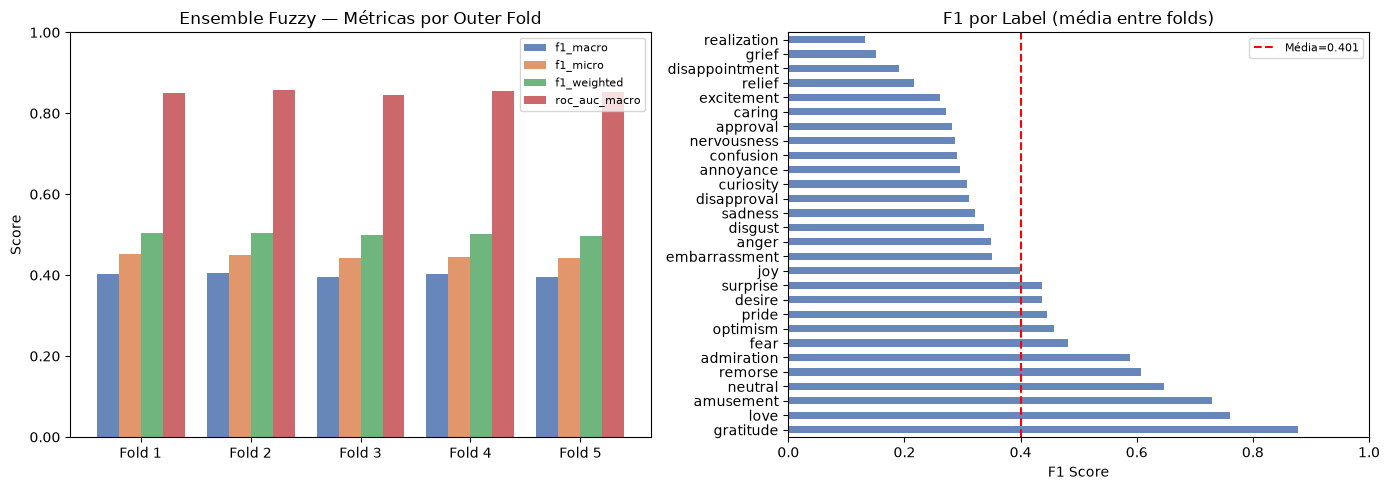

Figura salva em ..\data\out\ensemble_fuzzy\ensemble_fuzzy_metrics.png


In [17]:
# ── Gráficos no mesmo formato dos baselines ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_plot = ["f1_macro", "f1_micro", "f1_weighted", "roc_auc_macro"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = axes[0]
x = np.arange(len(df_results))
width = 0.20
for i, (met, col) in enumerate(zip(metric_plot, colors)):
    ax.bar(x + i * width, df_results[met], width, label=met, color=col, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Fold {k}" for k in df_results.index])
ax.set_ylim(0, 1)
ax.set_title("Ensemble Fuzzy — Métricas por Outer Fold")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score")

ax2 = axes[1]
f1_per_label_mean.plot.barh(ax=ax2, color="#4C72B0", alpha=0.85)
ax2.set_title("F1 por Label (média entre folds)")
ax2.set_xlabel("F1 Score")
ax2.set_xlim(0, 1)
ax2.axvline(f1_per_label_mean.mean(), color="red", linestyle="--",
            label=f"Média={f1_per_label_mean.mean():.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_fuzzy_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'ensemble_fuzzy_metrics.png'}")

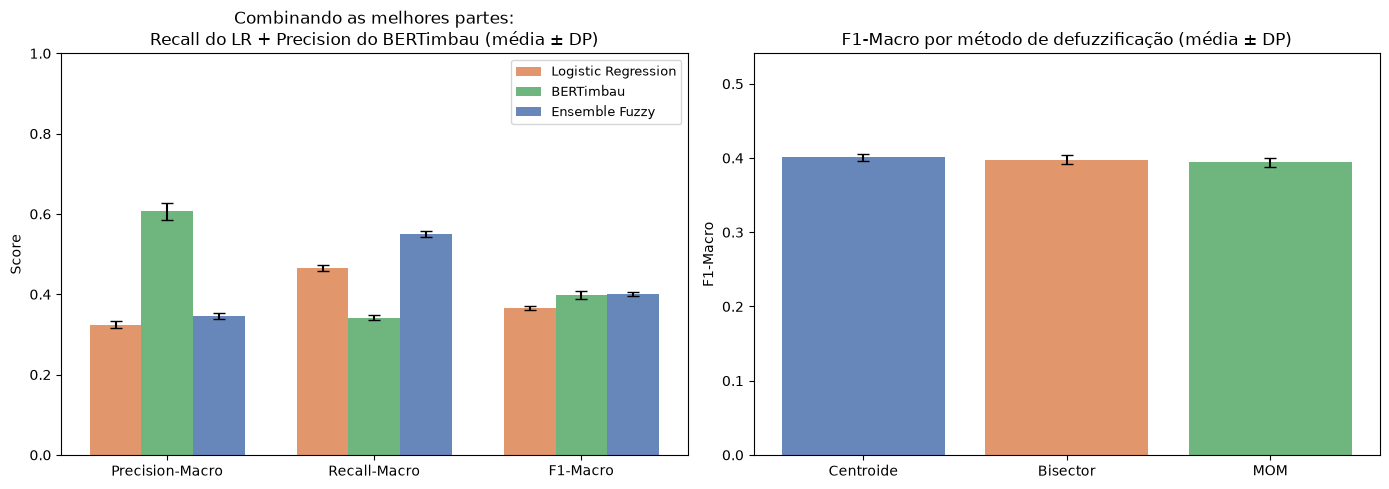

Figura salva em ..\data\out\ensemble_fuzzy\ensemble_fuzzy_comparacao.png


In [18]:
# ── "As melhores partes": Precision (BERT) + Recall (LR) → F1 (Fuzzy) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["Logistic Regression", "BERTimbau", "Ensemble Fuzzy"]
dfs    = [df_lr, df_bert, df_fz]
mcolors = ["#DD8452", "#55A868", "#4C72B0"]

ax = axes[0]
mets = ["precision_macro", "recall_macro", "f1_macro"]
met_labels = ["Precision-Macro", "Recall-Macro", "F1-Macro"]
x = np.arange(len(mets)); width = 0.25
for i, (name, d, c) in enumerate(zip(models, dfs, mcolors)):
    means = [d[m].mean() for m in mets]
    stds  = [d[m].std()  for m in mets]
    ax.bar(x + i * width, means, width, yerr=stds, capsize=4,
           label=name, color=c, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(met_labels)
ax.set_ylim(0, 1)
ax.set_title("Combinando as melhores partes:\nRecall do LR + Precision do BERTimbau (média ± DP)")
ax.legend(fontsize=9)
ax.set_ylabel("Score")

ax3 = axes[1]
defz_means = {m: np.mean([x["f1_macro"] for x in method_fold_metrics[m]]) for m in DEFUZZ_METHODS}
defz_stds  = {m: np.std([x["f1_macro"] for x in method_fold_metrics[m]], ddof=1) for m in DEFUZZ_METHODS}
names = {"centroid": "Centroide", "bisector": "Bisector", "mom": "MOM"}
ax3.bar([names[m] for m in DEFUZZ_METHODS],
        [defz_means[m] for m in DEFUZZ_METHODS],
        yerr=[defz_stds[m] for m in DEFUZZ_METHODS],
        capsize=4, color=["#4C72B0", "#DD8452", "#55A868"], alpha=0.85)
ax3.set_title("F1-Macro por método de defuzzificação (média ± DP)")
ax3.set_ylabel("F1-Macro")
ax3.set_ylim(0, max(defz_means.values()) * 1.35)

plt.tight_layout()
plt.savefig(OUT_DIR / "ensemble_fuzzy_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura salva em {OUT_DIR / 'ensemble_fuzzy_comparacao.png'}")

## 10. Interpretabilidade — Pertinência Emocional (bloco 9)

A saída do sistema **não é uma probabilidade**: é o **grau de pertinência** ∈ [0,1] do
texto em cada conjunto fuzzy de emoção — o resultado da defuzzificação da MF agregada
pelas regras. Um texto pode ter pertinência alta em várias emoções simultaneamente, e os
graus **não somam 1** nem carregam interpretação frequentista; eles medem *compatibilidade
graduada* do texto com cada emoção, apoiando a análise da **intensidade emocional** e a
tomada de decisão.

Abaixo: (i) as **funções de pertinência geradas automaticamente** (FCM) e as **regras
geradas automaticamente** (Wang–Mendel) de uma emoção; (ii) a distribuição dos graus de
pertinência separada por classe verdadeira; (iii) a função `explicar_texto`, que mostra a
fuzzificação, as regras disparadas e a defuzzificação para um texto individual.

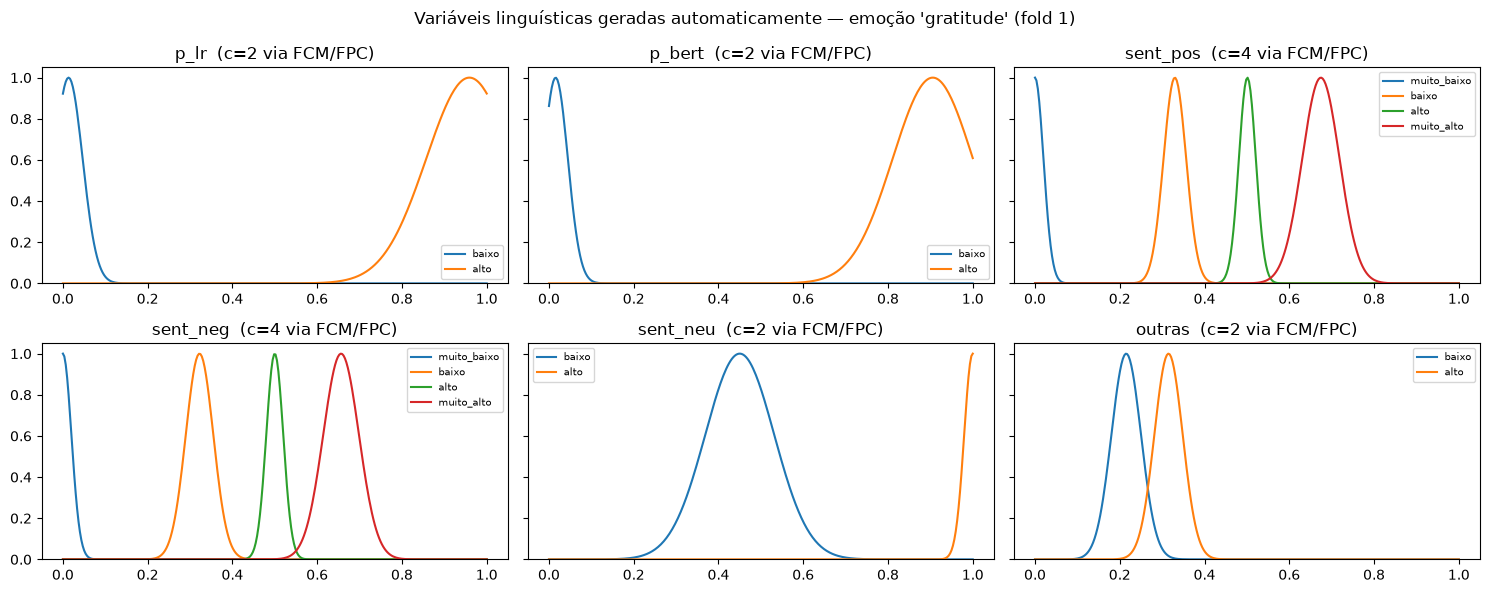

Base de regras da emoção 'gratitude' (fold 1): 60 regras geradas (Wang–Mendel). Top 12 por suporte:

  SE p_lr é BAIXO E p_bert é BAIXO E sent_pos é MUITO_BAIXO E sent_neg é MUITO_BAIXO E sent_neu é ALTO E outras é BAIXO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.97, suporte=8254.7]
  SE p_lr é BAIXO E p_bert é BAIXO E sent_pos é MUITO_BAIXO E sent_neg é MUITO_BAIXO E sent_neu é ALTO E outras é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.98, suporte=7583.2]
  SE p_lr é ALTO E p_bert é ALTO E sent_pos é ALTO E sent_neg é MUITO_BAIXO E sent_neu é BAIXO E outras é ALTO ENTÃO pertinência(gratitude) é ALTA  [conf=1.00, suporte=4838.0]
  SE p_lr é ALTO E p_bert é ALTO E sent_pos é ALTO E sent_neg é MUITO_BAIXO E sent_neu é BAIXO E outras é BAIXO ENTÃO pertinência(gratitude) é ALTA  [conf=1.00, suporte=4251.6]
  SE p_lr é BAIXO E p_bert é BAIXO E sent_pos é ALTO E sent_neg é MUITO_BAIXO E sent_neu é BAIXO E outras é ALTO ENTÃO pertinência(gratitude) é BAIXA  [conf=0.91, suporte=1703

In [19]:
# ── (i) MFs e regras geradas automaticamente — exemplo ───────────
EMO_DEMO  = "gratitude"   # troque para inspecionar outra emoção
FOLD_DEMO = 1
sys_demo = fuzzy_systems[FOLD_DEMO][EMO_DEMO]

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharey=True)
xx = np.linspace(0, 1, 300)
for ax, fv in zip(axes.ravel(), sys_demo["fvars"]):
    M = fv.memberships(xx)
    for t in range(fv.n_terms):
        ax.plot(xx, M[:, t], label=fv.terms[t])
    ax.set_title(f"{fv.name}  (c={fv.n_terms} via FCM/FPC)")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
fig.suptitle(f"Variáveis linguísticas geradas automaticamente — emoção '{EMO_DEMO}' (fold {FOLD_DEMO})")
plt.tight_layout()
plt.savefig(OUT_DIR / f"mfs_{EMO_DEMO}_fold{FOLD_DEMO}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Base de regras da emoção '{EMO_DEMO}' (fold {FOLD_DEMO}): "
      f"{len(sys_demo['rules'])} regras geradas (Wang–Mendel). Top 12 por suporte:\n")
for r in sys_demo["rules"][:12]:
    print(" ", rule_to_text(r, sys_demo["fvars"], EMO_DEMO))
print(f"\nLimiar de decisão por defuzz (calibração): "
      f"{ {m: round(t,2) for m,t in sys_demo['thresholds'].items()} } | "
      f"peso de classe positiva: {sys_demo['pos_weight']:.1f}")

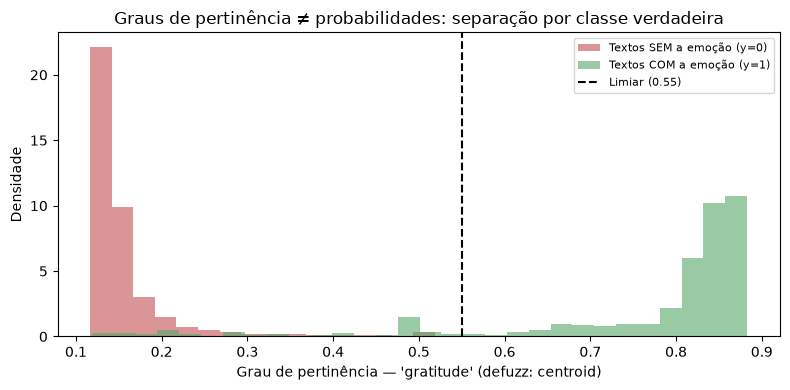

TEXTO (fold 1, idx 11): "obrigada realmente aprecio sua resposta"
Emoção analisada: gratitude | rótulo verdadeiro: 1

Entradas crisp: p_lr=1.000 | p_bert=0.949 | sent_pos=0.500 | sent_neg=0.000 | sent_neu=0.500 | outras=0.222

Fuzzificação (grau em cada termo linguístico):
  p_lr     : baixo=0.00, alto=0.92
  p_bert   : baixo=0.00, alto=0.90
  sent_pos : muito_baixo=0.00, baixo=0.00, alto=1.00, muito_alto=0.00
  sent_neg : muito_baixo=1.00, baixo=0.00, alto=0.00, muito_alto=0.00
  sent_neu : baixo=0.83, alto=0.00
  outras   : baixo=0.98, alto=0.02

Top 5 regras disparadas:
  [0.673] SE p_lr é ALTO E p_bert é ALTO E sent_pos é ALTO E sent_neg é MUITO_BAIXO E sent_neu é BAIXO E outras é BAIXO ENTÃO pertinência(gratitude) é ALTA  [conf=1.00, suporte=4251.6]
  [0.015] SE p_lr é ALTO E p_bert é ALTO E sent_pos é ALTO E sent_neg é MUITO_BAIXO E sent_neu é BAIXO E outras é ALTO ENTÃO pertinência(gratitude) é ALTA  [conf=1.00, suporte=4838.0]
  [0.000] SE p_lr é ALTO E p_bert é ALTO E sent_pos

In [20]:
# ── (ii) Distribuição dos graus de pertinência por classe verdadeira ──
sel = selected_methods[FOLD_DEMO]
j_demo = EMOTION_COLS.index(EMO_DEMO)
pert = pertinence_test[FOLD_DEMO][sel][:, j_demo]
y_true_demo = Y_folds[FOLD_DEMO][:, j_demo]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pert[y_true_demo == 0], bins=30, alpha=0.6, density=True,
        label="Textos SEM a emoção (y=0)", color="#C44E52")
ax.hist(pert[y_true_demo == 1], bins=30, alpha=0.6, density=True,
        label="Textos COM a emoção (y=1)", color="#55A868")
ax.axvline(sys_demo["thresholds"][sel], color="k", linestyle="--",
           label=f"Limiar ({sys_demo['thresholds'][sel]:.2f})")
ax.set_xlabel(f"Grau de pertinência — '{EMO_DEMO}' (defuzz: {sel})")
ax.set_ylabel("Densidade")
ax.set_title("Graus de pertinência ≠ probabilidades: separação por classe verdadeira")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / f"pertinencia_{EMO_DEMO}_fold{FOLD_DEMO}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── (iii) Explicação de um texto individual ──────────────────────
def explicar_texto(fold, i, emotion, top_rules=5):
    """Mostra fuzzificação, regras disparadas e defuzzificação de um texto."""
    j = EMOTION_COLS.index(emotion)
    system = fuzzy_systems[fold][emotion]
    outras_cal, outras_te = aggregate_outras(
        np.vstack([LEX_folds[k] for k in folds_data if k != fold]), LEX_folds[fold])
    inp = build_emotion_inputs(j, P_LR_folds[fold], P_BERT_folds[fold],
                               SENT_folds[fold], outras_te)
    x = {v: inp[v][i] for v in INPUT_VARS}

    print(f"TEXTO (fold {fold}, idx {i}): \"{TEXT_folds[fold][i][:200]}\"")
    print(f"Emoção analisada: {emotion} | rótulo verdadeiro: {Y_folds[fold][i, j]}")
    print(f"\nEntradas crisp: " + " | ".join(f"{v}={x[v]:.3f}" for v in INPUT_VARS))

    print("\nFuzzificação (grau em cada termo linguístico):")
    M_i = []
    for fv in system["fvars"]:
        mu = fv.memberships(np.array([x[fv.name]]))[0]
        M_i.append(mu)
        print(f"  {fv.name:9s}: " + ", ".join(f"{t}={m:.2f}" for t, m in zip(fv.terms, mu)))

    fires = []
    for r in system["rules"]:
        f = np.prod([M_i[q][a] for q, a in enumerate(r["antecedent"])]) * r["conf"]
        fires.append((f, r))
    fires.sort(key=lambda z: z[0], reverse=True)
    print(f"\nTop {top_rules} regras disparadas:")
    for f, r in fires[:top_rules]:
        print(f"  [{f:.3f}] {rule_to_text(r, system['fvars'], emotion)}")

    M_list = [fv.memberships(np.array([x[fv.name]])) for fv in system["fvars"]]
    W = fuzzy_inference(M_list, system["rules"])
    pj = defuzzify(W)
    print("\nGraus de pertinência (defuzzificação):")
    for m, p in pj.items():
        thr = system["thresholds"][m]
        dec = "PRESENTE" if p[0] >= thr else "ausente"
        print(f"  {m:9s}: pertinência = {p[0]:.3f}  (limiar {thr:.2f} → {dec})")

def pertinencias_do_texto(fold, i):
    """Vetor completo de graus de pertinência (28 emoções) de um texto — bloco 9."""
    sel = selected_methods[fold]
    s = pd.Series(pertinence_test[fold][sel][i], index=EMOTION_COLS)
    return s.sort_values(ascending=False)

# Demonstração: um texto positivo do fold de demonstração
cand = np.where(y_true_demo == 1)[0]
i_demo = int(cand[0]) if len(cand) else 0
explicar_texto(FOLD_DEMO, i_demo, EMO_DEMO)
print("\nGraus de pertinência de TODAS as emoções para esse texto (top 8):")
print(pertinencias_do_texto(FOLD_DEMO, i_demo).head(8).round(3))

## 11. Análise de erros

Foco na tese do ensemble: quantos **falsos negativos do BERTimbau** o Fuzzy recupera
(herança do *recall* do LR) e quantos **falsos positivos do LR** o Fuzzy elimina
(herança da *precision* do BERTimbau) — agregados sobre os 5 outer folds — além dos
casos em que o Fuzzy piora (custo do compromisso) e exemplos qualitativos.

In [21]:
# ── Recuperações e correções agregadas sobre os 5 folds ──────────
tot = dict(fn_bert=0, fn_bert_recuperados=0, fp_lr=0, fp_lr_corrigidos=0,
           novos_fp=0, novos_fn=0)

for k in folds_data:
    Yt = Y_folds[k]
    pf, pl, pb = pred_store[k]["fuzzy"], pred_store[k]["lr"], pred_store[k]["bert"]

    fn_bert = (Yt == 1) & (pb == 0)
    tot["fn_bert"] += int(fn_bert.sum())
    tot["fn_bert_recuperados"] += int((fn_bert & (pf == 1)).sum())

    fp_lr = (Yt == 0) & (pl == 1)
    tot["fp_lr"] += int(fp_lr.sum())
    tot["fp_lr_corrigidos"] += int((fp_lr & (pf == 0)).sum())

    tot["novos_fp"] += int(((Yt == 0) & (pf == 1) & (pl == 0) & (pb == 0)).sum())
    tot["novos_fn"] += int(((Yt == 1) & (pf == 0) & ((pl == 1) | (pb == 1))).sum())

print("===== ANÁLISE DE ERROS (agregado, 5 outer folds) =====")
print(f"Falsos negativos do BERTimbau ............: {tot['fn_bert']}")
print(f"  → recuperados pelo Fuzzy (ganho recall) : {tot['fn_bert_recuperados']} "
      f"({100*tot['fn_bert_recuperados']/max(tot['fn_bert'],1):.1f}%)")
print(f"Falsos positivos do LR ...................: {tot['fp_lr']}")
print(f"  → corrigidos pelo Fuzzy (ganho precision): {tot['fp_lr_corrigidos']} "
      f"({100*tot['fp_lr_corrigidos']/max(tot['fp_lr'],1):.1f}%)")
print(f"Novos FP introduzidos pelo Fuzzy .........: {tot['novos_fp']}")
print(f"Novos FN introduzidos pelo Fuzzy .........: {tot['novos_fn']}")

# ── Labels com maior ganho/perda vs melhor baseline ──────────────
print("\nTop 5 emoções com MAIOR ganho de F1 (vs melhor baseline):")
display(df_label_comp.sort_values("Δ vs melhor baseline", ascending=False)
        .head(5)[["Fuzzy", "LR", "BERTimbau", "Δ vs melhor baseline"]].round(4))
print("Top 5 emoções com PIOR resultado (vs melhor baseline):")
display(df_label_comp.sort_values("Δ vs melhor baseline")
        .head(5)[["Fuzzy", "LR", "BERTimbau", "Δ vs melhor baseline"]].round(4))

# ── Exemplos qualitativos ────────────────────────────────────────
def exemplos(cond_fn, titulo, n_show=3):
    print(f"\n───── {titulo} ─────")
    shown = 0
    for k in folds_data:
        Yt = Y_folds[k]
        pf, pl, pb = pred_store[k]["fuzzy"], pred_store[k]["lr"], pred_store[k]["bert"]
        mask = cond_fn(Yt, pf, pl, pb)
        idxs = np.argwhere(mask)
        for i, j in idxs[: max(0, n_show - shown)]:
            sel_k = selected_methods[k]
            print(f"  [fold {k} | {EMOTION_COLS[j]}] "
                  f"P_LR={P_LR_folds[k][i, j]:.2f} P_BERT={P_BERT_folds[k][i, j]:.2f} "
                  f"pertinência={pertinence_test[k][sel_k][i, j]:.2f}")
            print(f"    \"{TEXT_folds[k][i][:140]}\"")
            shown += 1
        if shown >= n_show:
            break

exemplos(lambda Y, f, l, b: (Y == 1) & (b == 0) & (f == 1),
         "FN do BERTimbau recuperados pelo Fuzzy (recall herdado do LR)")
exemplos(lambda Y, f, l, b: (Y == 0) & (l == 1) & (f == 0),
         "FP do LR corrigidos pelo Fuzzy (precision herdada do BERTimbau)")
exemplos(lambda Y, f, l, b: (Y == 1) & (f == 0) & ((l == 1) | (b == 1)),
         "Casos em que o Fuzzy perdeu um acerto de algum baseline (custo do compromisso)")

===== ANÁLISE DE ERROS (agregado, 5 outer folds) =====
Falsos negativos do BERTimbau ............: 38115
  → recuperados pelo Fuzzy (ganho recall) : 17013 (44.6%)
Falsos positivos do LR ...................: 67533
  → corrigidos pelo Fuzzy (ganho precision): 32903 (48.7%)
Novos FP introduzidos pelo Fuzzy .........: 43896
Novos FN introduzidos pelo Fuzzy .........: 4456

Top 5 emoções com MAIOR ganho de F1 (vs melhor baseline):


,Fuzzy,LR,BERTimbau,Δ vs melhor baseline
curiosity,0.3085,0.2179,0.1828,0.0905
annoyance,0.2953,0.2092,0.0045,0.0862
disapproval,0.3113,0.2326,0.1356,0.0787
approval,0.2820,0.2080,0.0945,0.0739
neutral,0.6477,0.5798,0.5857,0.0619


Top 5 emoções com PIOR resultado (vs melhor baseline):


,Fuzzy,LR,BERTimbau,Δ vs melhor baseline
sadness,0.3220,0.3926,0.4637,-0.1417
embarrassment,0.3504,0.1611,0.4643,-0.1140
grief,0.1507,0.1985,0.2588,-0.1081
fear,0.4811,0.3751,0.5735,-0.0925
nervousness,0.2877,0.2093,0.3583,-0.0706



───── FN do BERTimbau recuperados pelo Fuzzy (recall herdado do LR) ─────
  [fold 1 | caring] P_LR=0.92 P_BERT=0.08 pertinência=0.77
    "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"
  [fold 1 | annoyance] P_LR=0.13 P_BERT=0.28 pertinência=0.85
    "isso cheira positivamente lar abusivo"
  [fold 1 | excitement] P_LR=0.95 P_BERT=0.40 pertinência=0.82
    "vamos colocar coisas volta nos trilhos feliz ano novo"

───── FP do LR corrigidos pelo Fuzzy (precision herdada do BERTimbau) ─────
  [fold 1 | annoyance] P_LR=0.52 P_BERT=0.08 pertinência=0.41
    "tanto tempo economizado nao"
  [fold 1 | approval] P_LR=0.50 P_BERT=0.03 pertinência=0.51
    "tanto tempo economizado nao"
  [fold 1 | realization] P_LR=0.52 P_BERT=0.01 pertinência=0.19
    "fico feliz ouvi-lo voce merece sua melhor vida sem esse abuso negatividade"

───── Casos em que o Fuzzy perdeu um acerto de algum baseline (custo do compromisso) ─────
  [fold 1 | curiosity] P_LR=0.98 P_BERT=0.11 pertin

## 12. Exportação dos resultados

Mesmo padrão dos baselines: CSVs de métricas globais e por label, resumo em JSON, e —
saída específica do bloco 9 — os **graus de pertinência emocional** de todas as amostras
(out-of-fold, cobrindo o dataset inteiro) em parquet.

In [22]:
# ── Métricas globais / por label / comparação ────────────────────
df_results.to_csv(OUT_DIR / "ensemble_fuzzy_global_metrics.csv")
f1_per_label_folds.to_csv(OUT_DIR / "ensemble_fuzzy_f1_per_label.csv")
df_comparison.to_csv(OUT_DIR / "comparacao_LR_BERT_Fuzzy.csv")
df_label_comp.to_csv(OUT_DIR / "f1_por_label_comparacao.csv")
df_defuzz.to_csv(OUT_DIR / "comparacao_defuzzificacao.csv")

# ── Graus de pertinência (bloco 9) — dataset completo, out-of-fold ─
pert_frames = []
for k in folds_data:
    sel_k = selected_methods[k]
    dfp = pd.DataFrame(pertinence_test[k][sel_k],
                       columns=[f"pert_{e}" for e in EMOTION_COLS])
    dfp.insert(0, "fold", k)
    dfp.insert(1, "defuzz", sel_k)
    dfp.insert(2, TEXT_COL, TEXT_folds[k])
    for j, e in enumerate(EMOTION_COLS):
        dfp[f"pred_{e}"] = pred_store[k]["fuzzy"][:, j]
        dfp[f"true_{e}"] = Y_folds[k][:, j]
    pert_frames.append(dfp)
df_pertinencias = pd.concat(pert_frames, ignore_index=True)
df_pertinencias.to_parquet(OUT_DIR / "graus_pertinencia_oof.parquet", index=False)

# ── Base de regras exportada (interpretabilidade/auditoria) ──────
rules_records = []
for k, systems in fuzzy_systems.items():
    for emo, s in systems.items():
        for r in s["rules"]:
            rules_records.append({
                "fold": k, "emocao": emo,
                "regra": rule_to_text(r, s["fvars"], emo),
                "consequente": OUT_TERMS[r["consequent"]],
                "confianca": round(r["conf"], 4),
                "suporte": round(r["support"], 2),
            })
pd.DataFrame(rules_records).to_csv(OUT_DIR / "base_de_regras.csv", index=False)

# ── Resumo final JSON ────────────────────────────────────────────
summary_dict = {
    "model": "Ensemble Fuzzy Mamdani (LR + BERTimbau + sentimento + features léxicas)",
    "base_teorica": "Anwar et al. (2024), PLoS ONE 19(5):e0300279 — fuzzy ensemble de modelos",
    "geracao_mfs": f"Fuzzy C-Means (c escolhido por FPC em {list(FCM_C_CANDIDATES)}), MFs gaussianas",
    "geracao_regras": f"Wang–Mendel (máx. {MAX_RULES} regras/emoção, ponderação de classe)",
    "defuzzificacao": {"metodos_avaliados": list(DEFUZZ_METHODS),
                       "selecionado_por_fold": {str(k): v for k, v in selected_methods.items()}},
    "sentiment_backend": SENTIMENT_BACKEND,
    "strategy": f"Nested CV ({N_OUTER_FOLDS} outer folds; calibração fuzzy 100% no outer-train, OOF)",
    "n_labels": N_LABELS,
    "f1_macro_mean": round(float(df_results["f1_macro"].mean()), 4),
    "f1_macro_std" : round(float(df_results["f1_macro"].std()),  4),
    "f1_micro_mean": round(float(df_results["f1_micro"].mean()), 4),
    "f1_micro_std" : round(float(df_results["f1_micro"].std()),  4),
    "precision_macro_mean": round(float(df_results["precision_macro"].mean()), 4),
    "precision_macro_std" : round(float(df_results["precision_macro"].std()),  4),
    "recall_macro_mean": round(float(df_results["recall_macro"].mean()), 4),
    "recall_macro_std" : round(float(df_results["recall_macro"].std()),  4),
    "roc_auc_mean": round(float(df_results["roc_auc_macro"].mean()), 4),
    "roc_auc_std" : round(float(df_results["roc_auc_macro"].std()),  4),
    "wilcoxon": wilcoxon_results,
    "baselines_no_mesmo_protocolo": {
        "LR":   {"f1_macro": f"{df_lr['f1_macro'].mean():.4f} ± {df_lr['f1_macro'].std():.4f}",
                 "precision_macro": f"{df_lr['precision_macro'].mean():.4f}",
                 "recall_macro": f"{df_lr['recall_macro'].mean():.4f}"},
        "BERT": {"f1_macro": f"{df_bert['f1_macro'].mean():.4f} ± {df_bert['f1_macro'].std():.4f}",
                 "precision_macro": f"{df_bert['precision_macro'].mean():.4f}",
                 "recall_macro": f"{df_bert['recall_macro'].mean():.4f}"},
    },
}
with open(OUT_DIR / "ensemble_fuzzy_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2, ensure_ascii=False)

print("Arquivos exportados para", OUT_DIR.resolve())
print(json.dumps(summary_dict, indent=2, ensure_ascii=False))

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\ensemble_fuzzy
{
  "model": "Ensemble Fuzzy Mamdani (LR + BERTimbau + sentimento + features léxicas)",
  "base_teorica": "Anwar et al. (2024), PLoS ONE 19(5):e0300279 — fuzzy ensemble de modelos",
  "geracao_mfs": "Fuzzy C-Means (c escolhido por FPC em [2, 3, 4]), MFs gaussianas",
  "geracao_regras": "Wang–Mendel (máx. 60 regras/emoção, ponderação de classe)",
  "defuzzificacao": {
    "metodos_avaliados": [
      "centroid",
      "bisector",
      "mom"
    ],
    "selecionado_por_fold": {
      "1": "centroid",
      "2": "centroid",
      "3": "centroid",
      "4": "centroid",
      "5": "centroid"
    }
  },
  "sentiment_backend": "lexicon",
  "strategy": "Nested CV (5 outer folds; calibração fuzzy 100% no outer-train, OOF)",
  "n_labels": 28,
  "f1_macro_mean": 0.4008,
  "f1_macro_std": 0.0051,
  "f1_micro_mean": 0.4457,
  "f1_micro_std": 0.0045,
  "precision_macro_